<a href="https://colab.research.google.com/github/stephenkeyy77/ECON3916-Statistical-Machine-Learning/blob/main/Lab5/Lab_5_Probability_%E2%80%94_The_Engine_of_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
np.random.randint(10000, 100000)

34163

55524

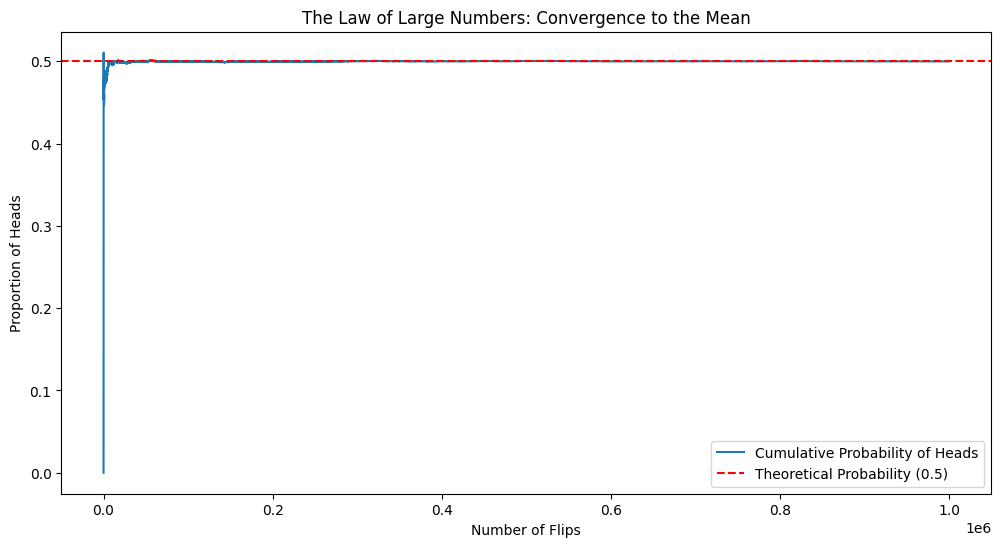

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_law_of_large_numbers(n_flips):
  if n_flips >= 2:
    # Simulate n_flips of a fair coin (0 or 1)
    #flips = np.random.randint(0, 2, size=n_flips)
    flips = np.random.choice([0, 1], size=n_flips, p = [0.5, 0.5])

    # Calculate cumulative average
    # cumsum adds them up sequentially
    # Divide by range(1, n+1) to get average at each step
    cumulative_averages = np.cumsum(flips) / np.arange(1, n_flips + 1)



    # Visualization
    plt.figure(figsize=(12, 6))
    plt.plot(cumulative_averages, label='Cumulative Probability of Heads')
    plt.axhline(0.5, color='red', linestyle='--', label='Theoretical Probability (0.5)')
    plt.title('The Law of Large Numbers: Convergence to the Mean')
    plt.xlabel('Number of Flips')
    plt.ylabel('Proportion of Heads')
    plt.legend()
    plt.show()
  else:
    print("!!!n_flips must be greater than 2")

# Run the simulation
simulate_law_of_large_numbers(1000000)

In [ ]:
# topic: independent vs. "engineered randomness"
#context: the gambler's play

songs = ['Song A', 'Song B', 'Song C']
n_plays=20

# 1. true random (independent events - the "coin flip")
# this represents a "fair" system where the past does not predict the future
playlist_random = np.random.choice(songs, size = n_plays)

# 2. engineered shuffle (dependent events - "spotify mode")
# we force it to not repeat the last song
playlist_engineered = []
last_song = None

for _ in range(n_plays):
  #create a list of a allowed songs (exclude the one just played)
  allowed = [s for s in songs if s !=last_song]
  # pick from the allowed list
  pick = np.random.choice(allowed)
  # add to the playlist
  last_song = pick
  playlist_engineered += [pick]


print ("--- true random (notice the 'clumps)---")
print(playlist_random)

--- true random (notice the 'clumps)---
['Song B' 'Song B' 'Song C' 'Song A' 'Song C' 'Song C' 'Song B' 'Song C'
 'Song B' 'Song C' 'Song A' 'Song B' 'Song B' 'Song A' 'Song C' 'Song B'
 'Song B' 'Song B' 'Song A' 'Song A']


In [ ]:
def monty_hall_sim(n_games):
    switch_wins = 0
    stay_wins = 0

    for _ in range(n_games):
        doors = [0, 1, 2]
        prize = np.random.choice(doors)
        choice = np.random.choice(doors)

        # Host opens a door
        # Host cannot open 'prize' and cannot open 'choice'
        openable_doors = [d for d in doors if d != prize and d != choice]
        host_opens = np.random.choice(openable_doors)

        # Strategy: Stay
        if choice == prize:
            stay_wins += 1

        # Strategy: Switch
        # The switch choice is the door that is not 'choice' and not 'host_opens'
        switch_choice = [d for d in doors if d != choice and d != host_opens]
        if switch_choice[0] == prize:
            switch_wins += 1

    print(f"Win Rate (Stay): {stay_wins/n_games:.2%}")
    print(f"Win Rate (Switch): {switch_wins/n_games:.2%}")

monty_hall_sim(10000)

Win Rate (Stay): 33.70%
Win Rate (Switch): 66.30%


Probability of Revenue Decline: 17.92%
95% Value at Risk (Worst Case): $9,595,687.65


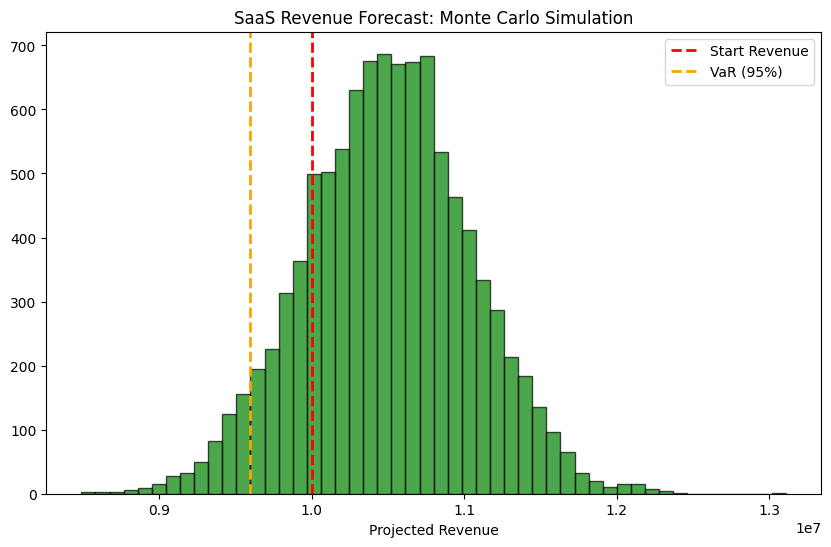

In [ ]:
def saas_risk_model(n_sims):
    base_rev = 10_000_000

    # Stochastic Inputs
    # Churn is centered at 10% but can vary (Standard Deviation 2%)
    churn_sims = np.random.normal(0.10, 0.02, n_sims)
    # Sales centered at $1.5M, varies by $500k
    sales_sims = np.random.normal(1_500_000, 500_000, n_sims)

    # The Transfer Function (The Business Logic)
    net_revenue = base_rev * (1 - churn_sims) + sales_sims

    # Risk Metrics
    # Probability that we end the year with LESS money than we started
    prob_loss = np.mean(net_revenue < base_rev)

    # Value at Risk (95% Confidence)
    # We are 95% sure revenue will be ABOVE this number (the 5th percentile)
    var_95 = np.percentile(net_revenue, 5)

    print(f"Probability of Revenue Decline: {prob_loss:.2%}")
    print(f"95% Value at Risk (Worst Case): ${var_95:,.2f}")

    # Visualization
    plt.figure(figsize=(10,6))
    plt.hist(net_revenue, bins=50, alpha=0.7, color='green', edgecolor='black')
    plt.axvline(base_rev, color='red', linestyle='dashed', linewidth=2, label='Start Revenue')
    plt.axvline(var_95, color='orange', linestyle='dashed', linewidth=2, label='VaR (95%)')
    plt.title('SaaS Revenue Forecast: Monte Carlo Simulation')
    plt.xlabel('Projected Revenue')
    plt.legend()
    plt.show()

saas_risk_model(10000)